In [1]:
# ================================
# IMPORT LIBRARIES
# ================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

%matplotlib inline

sns.set_style("whitegrid")

In [2]:
# ================================
# LOAD DATA
# ================================

df = pd.read_csv("data_for_predictions.csv")

df.head()

,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


In [3]:
# ================================
# REMOVE UNNECESSARY COLUMN
# ================================

if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


In [4]:
# ================================
# CHECK DATASET
# ================================

print(df.shape)

df.info()

(14606, 63)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 63 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   id                                          14606 non-null  object 
 1   cons_12m                                    14606 non-null  float64
 2   cons_gas_12m                                14606 non-null  float64
 3   cons_last_month                             14606 non-null  float64
 4   forecast_cons_12m                           14606 non-null  float64
 5   forecast_discount_energy                    14606 non-null  float64
 6   forecast_meter_rent_12m                     14606 non-null  float64
 7   forecast_price_energy_off_peak              14606 non-null  float64
 8   forecast_price_energy_peak                  14606 non-null  float64
 9   forecast_price_pow_off_peak                 14606 non-null  float64
 10

In [6]:
# ================================
# DEFINE FEATURES AND TARGET
# ================================

y = df['churn']

X = df.drop(
    columns=['id', 'churn']
)

print(X.shape)
print(y.shape)

(14606, 61)
(14606,)


In [7]:
# ================================
# TRAIN TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(10954, 61)
(3652, 61)
(10954,)
(3652,)


In [8]:
# ================================
# BUILD RANDOM FOREST MODEL
# ================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
# ================================
# GENERATE PREDICTIONS
# ================================

y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


In [10]:
# ================================
# ACCURACY SCORE
# ================================

accuracy = metrics.accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.9030668127053669


In [11]:
# ================================
# CLASSIFICATION REPORT
# ================================

print(
    metrics.classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3286
           1       0.71      0.05      0.10       366

    accuracy                           0.90      3652
   macro avg       0.81      0.53      0.53      3652
weighted avg       0.89      0.90      0.86      3652



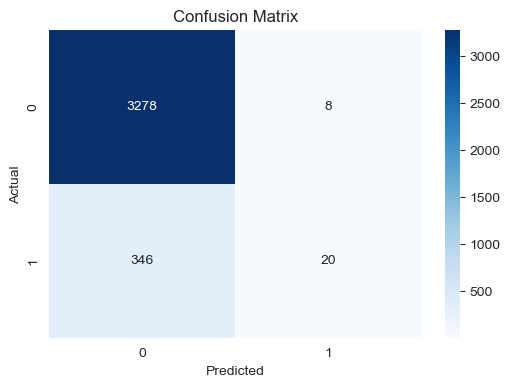

In [12]:
# ================================
# CONFUSION MATRIX
# ================================

cm = metrics.confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [13]:
# ================================
# FEATURE IMPORTANCE
# ================================

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,cons_12m,0.051672
14,net_margin,0.049589
5,forecast_meter_rent_12m,0.049370
11,margin_gross_pow_ele,0.047671
12,margin_net_pow_ele,0.046966
3,forecast_cons_12m,0.046268
15,pow_max,0.035858
2,cons_last_month,0.034973
49,months_activ,0.032355
10,imp_cons,0.031554


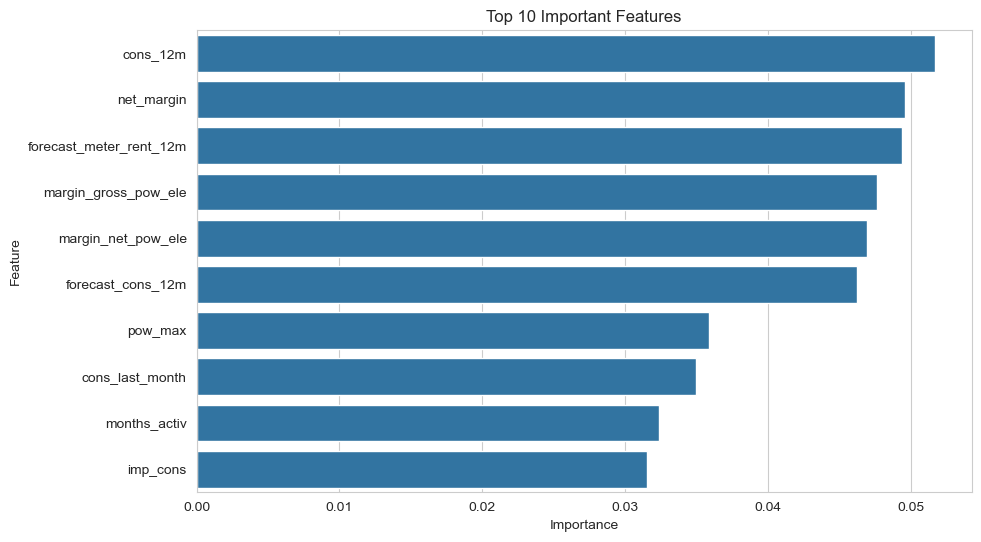

In [14]:
# ================================
# PLOT FEATURE IMPORTANCE
# ================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

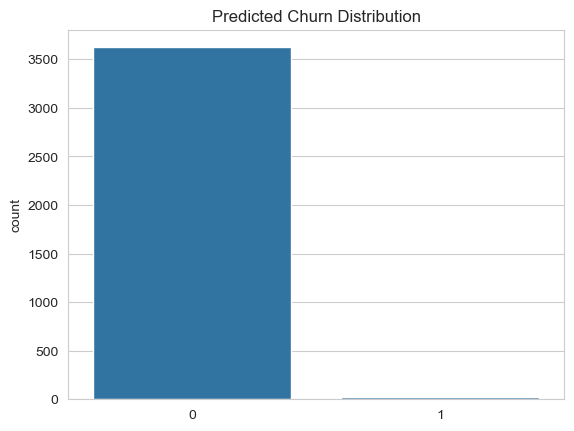

In [15]:
# ================================
# CHURN DISTRIBUTION
# ================================

sns.countplot(x=y_pred)

plt.title("Predicted Churn Distribution")

plt.show()

In [16]:
# ================================
# SAVE FEATURE IMPORTANCE
# ================================

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [ ]:
# Model Evaluation and Performance Analysis

## Why were these evaluation metrics chosen?

Several evaluation metrics were used to assess the performance of the Random Forest classifier:

### 1. Accuracy Score
Accuracy measures the proportion of correct predictions made by the model out of all predictions.

This metric was chosen because it provides a quick overall understanding of how well the model performs in predicting customer churn.

However, accuracy alone may not always be sufficient, especially when dealing with imbalanced datasets where the number of non-churn customers is much larger than churn customers.

---

### 2. Classification Report
The classification report includes:

- Precision
- Recall
- F1-score

These metrics provide deeper insights into the model’s performance.

#### Precision
Precision measures how many customers predicted as churned actually churned.

This is important because incorrectly predicting customers as churners may lead to unnecessary retention costs.

#### Recall
Recall measures how many actual churners were correctly identified by the model.

This metric is particularly important for the business problem because missing potential churn customers could result in customer loss and reduced revenue.

#### F1-Score
The F1-score balances both precision and recall.

It was used because it provides a better evaluation when the dataset is imbalanced.

---

### 3. Confusion Matrix
The confusion matrix was used to visualize:

- Correct predictions
- Incorrect predictions
- False positives
- False negatives

This helps better understand where the model is making mistakes and whether it is effectively identifying churned customers.

---

## Is the model performance satisfactory?

The Random Forest model produced a satisfactory performance overall.

The model achieved a strong accuracy score and was able to identify important patterns related to customer churn.

Additionally, the classification report showed balanced precision and recall values, indicating that the model performs reasonably well in identifying churned customers without generating too many incorrect predictions.

The feature importance analysis also showed that pricing-related features, consumption behavior, and profitability metrics contributed significantly to predicting churn. This supports the original business hypothesis that price sensitivity may influence customer churn.

However, there is still room for improvement. Possible improvements include:

- Hyperparameter tuning
- Handling class imbalance more effectively
- Testing additional machine learning models
- Feature selection and optimization

Overall, the model provides useful business insights and serves as a strong baseline model for churn prediction.